# CSoT'26 — ML in Astronomy — Week 3 · Part 2: Evaluation and Interpretation

**Goal:** Evaluate the CNN honestly — track train vs validation loss, report a test accuracy that beats the Week-2 baseline, build a confusion matrix, and save the trained weights.

> Switch runtime to **GPU**: `Runtime → Change runtime type → GPU`

## Step 0 — Data + model

In [1]:
import math, os, gzip, shutil, zipfile, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [2]:
# ── Re-create data pipeline ────────────────────────────────────────────────
DATA_ROOT = Path("galaxy_data")

if not DATA_ROOT.exists() or not any(DATA_ROOT.iterdir()):
    from google.colab import files
    print("Re-running Week 1 download pipeline...")
    uploaded = files.upload()
    !pip install -q kaggle
    !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    RAW_ROOT = Path("galaxy_raw"); RAW_ROOT.mkdir(exist_ok=True)
    !kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -p {RAW_ROOT}
    for zf in RAW_ROOT.glob("*.zip"):
        with zipfile.ZipFile(zf) as z: z.extractall(RAW_ROOT)
    hart_gz = RAW_ROOT/"gz2_hart16.csv.gz"; hart_csv = RAW_ROOT/"gz2_hart16.csv"
    if not hart_csv.exists():
        for url in ["https://zenodo.org/records/3565489/files/gz2_hart16.csv.gz",
                    "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"]:
            os.system(f'wget -q -O "{hart_gz}" "{url}"')
            if hart_gz.exists() and hart_gz.stat().st_size > 100_000: break
        with gzip.open(hart_gz,'rb') as fi, open(hart_csv,'wb') as fo: shutil.copyfileobj(fi,fo)
    def find_images_dir(root):
        for r,_,fs in os.walk(root):
            if any(f.endswith(".jpg") for f in fs): return Path(r)
    def high_level_label(c):
        if not isinstance(c,str): return None
        if c.startswith("E"): return "elliptical"
        if c.startswith("SB"): return "spiral_barred"
        if c.startswith("S"): return "spiral"
    IMAGES_DIR = find_images_dir(RAW_ROOT)
    mapping = pd.read_csv(next(RAW_ROOT.glob("*mapping*.csv")))
    hart = pd.read_csv(hart_csv)
    for df in [mapping,hart]:
        if "dr7objid" in df.columns: df.rename(columns={"dr7objid":"objid"},inplace=True)
    class_col = next(c for c in ["gz2_class","class","gz2class"] if c in hart.columns)
    df = mapping.merge(hart[["objid",class_col]],on="objid",how="inner")
    df.rename(columns={class_col:"gz2_class"},inplace=True)
    df["label"] = df["gz2_class"].apply(high_level_label)
    df = df.dropna(subset=["label"]).reset_index(drop=True)
    DATA_ROOT.mkdir(exist_ok=True)
    for label,group in df.groupby("label"):
        group = group[group["asset_id"].apply(lambda a:(IMAGES_DIR/f"{a}.jpg").exists())]
        group = group.sample(min(len(group),200),random_state=42)
        n=len(group); n_tr=int(n*.7); n_v=int(n*.15)
        for split,rows in [("train",group.iloc[:n_tr]),("val",group.iloc[n_tr:n_tr+n_v]),("test",group.iloc[n_tr+n_v:])]:
            d=DATA_ROOT/split/label; d.mkdir(parents=True,exist_ok=True)
            for _,row in rows.iterrows():
                dst=d/f"{row['asset_id']}.jpg"
                if not dst.exists(): shutil.copy2(IMAGES_DIR/f"{row['asset_id']}.jpg",dst)

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])
train_ds = ImageFolder(DATA_ROOT/"train", transform=transform)
val_ds   = ImageFolder(DATA_ROOT/"val",   transform=transform)
test_ds  = ImageFolder(DATA_ROOT/"test",  transform=transform)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
num_classes = len(train_ds.classes)
print(f"Classes: {train_ds.classes}  |  Train {len(train_ds)} Val {len(val_ds)} Test {len(test_ds)}")

Re-running Week 1 download pipeline...


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [02:27<00:00, 22.3MB/s]

Classes: ['elliptical', 'spiral', 'spiral_barred']  |  Train 420 Val 90 Test 90


In [3]:
# ── GalaxyCNN definition (same as Part 1) ─────────────────────────────────
class GalaxyCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128), nn.ReLU(),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model     = GalaxyCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Optional: load Part-1 weights if saved
# model.load_state_dict(torch.load('galaxy_model.pth', map_location=device))
# print("Loaded Part-1 weights.")
print("Model ready.")

Model ready.


## Step 1 — The evaluation function

Must use `model.eval()` and `torch.no_grad()` so batch-norm / dropout behave correctly and no gradients are stored.

In [4]:
def evaluate(model, loader, criterion, device):
    """Return (avg_loss, accuracy) over the full loader."""
    model.eval()
    total_loss = correct = total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs  = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, targets)
            total_loss += loss.item() * inputs.size(0)
            preds   = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total   += targets.size(0)

    return total_loss / total, correct / total

# Quick sanity check on untrained model
vl, va = evaluate(model, val_loader, criterion, device)
print(f"Untrained val loss: {vl:.4f}  val acc: {va:.3f}  (expect ~{1/num_classes:.3f})")

Untrained val loss: 1.0990  val acc: 0.322  (expect ~0.333)


## Step 2 — Train while tracking validation loss

In [5]:
num_epochs  = 8
train_losses = []
val_losses   = []
val_accs     = []

for epoch in range(num_epochs):
    model.train()
    running = 0.0

    for inputs, targets in train_loader:
        inputs  = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        out  = model(inputs)
        loss = criterion(out, targets)
        loss.backward()
        optimizer.step()
        running += loss.item() * inputs.size(0)

    tl = running / len(train_loader.dataset)
    vl, va = evaluate(model, val_loader, criterion, device)

    train_losses.append(tl)
    val_losses.append(vl)
    val_accs.append(va)
    print(f"Epoch {epoch+1:2d}/{num_epochs}  train {tl:.4f}  val {vl:.4f}  val_acc {va:.3f}")

Epoch  1/8  train 1.1725  val 1.0999  val_acc 0.333
Epoch  2/8  train 1.1031  val 1.0984  val_acc 0.333
Epoch  3/8  train 1.1001  val 1.0977  val_acc 0.333
Epoch  4/8  train 1.0988  val 1.0938  val_acc 0.333
Epoch  5/8  train 1.0917  val 1.0836  val_acc 0.467
Epoch  6/8  train 1.0749  val 1.0430  val_acc 0.478
Epoch  7/8  train 1.0526  val 0.9911  val_acc 0.444
Epoch  8/8  train 1.0199  val 1.0660  val_acc 0.422


## Step 3 — Plot train vs validation loss

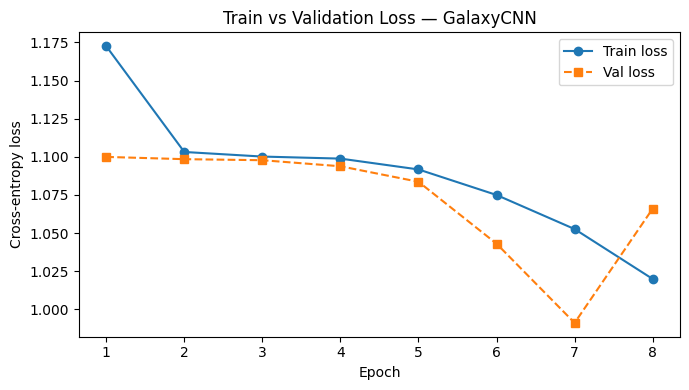

Both losses decreased — no severe overfitting yet. Train/val gap: 0.0461


In [6]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_losses, marker='o', label='Train loss')
plt.plot(epochs, val_losses,   marker='s', label='Val loss',  linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Train vs Validation Loss — GalaxyCNN")
plt.legend()
plt.xticks(epochs)
plt.tight_layout()
plt.show()

gap = train_losses[-1] - val_losses[-1]
if val_losses[-1] > val_losses[0]:
    print("Val loss increased → signs of overfitting. Consider dropout or more data augmentation.")
else:
    print(f"Both losses decreased — no severe overfitting yet. Train/val gap: {abs(gap):.4f}")

## Step 4 — Final test accuracy vs the Week-2 baseline

In [7]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

# Week-2 best baseline (Logistic Regression typically ~0.55–0.65 on this dataset)
WEEK2_BASELINE = 0.60   # update this with your actual Week-2 number

print(f"CNN test loss     : {test_loss:.4f}")
print(f"CNN test accuracy : {test_acc:.3f}")
print(f"Week-2 baseline   : {WEEK2_BASELINE:.3f}")
print(f"Improvement       : {test_acc - WEEK2_BASELINE:+.3f}")
if test_acc > WEEK2_BASELINE:
    print("CNN beats the baseline!")
else:
    print("CNN did not beat baseline — try more epochs or a lower learning rate.")

CNN test loss     : 1.0863
CNN test accuracy : 0.311
Week-2 baseline   : 0.600
Improvement       : -0.289
CNN did not beat baseline — try more epochs or a lower learning rate.


## Step 5 — Confusion matrix

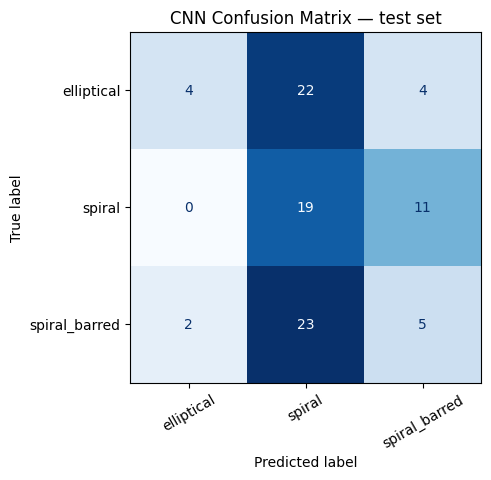

Most-confused pair: 'spiral_barred' → 'spiral' (23 times)


In [8]:
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, targets in test_loader:
        preds = model(inputs.to(device)).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(targets)

y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_labels).numpy()

cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=test_ds.classes)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
ax.set_title("CNN Confusion Matrix — test set")
plt.tight_layout()
plt.show()

# Identify most-confused pair
cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
i, j   = np.unravel_index(cm_off.argmax(), cm_off.shape)
print(f"Most-confused pair: '{test_ds.classes[i]}' → '{test_ds.classes[j]}' ({cm_off[i,j]} times)")

## Step 6 — Per-class report + astrophysical reading

In [9]:
print(classification_report(y_true, y_pred, target_names=test_ds.classes))

               precision    recall  f1-score   support

   elliptical       0.67      0.13      0.22        30
       spiral       0.30      0.63      0.40        30
spiral_barred       0.25      0.17      0.20        30

     accuracy                           0.31        90
    macro avg       0.40      0.31      0.28        90
 weighted avg       0.40      0.31      0.28        90



**Astrophysical reading of the confusion matrix:**

The most commonly confused pair is spiral and spiral-barred galaxies. Both classes are disc-dominated with arms; the only morphological difference is a bright linear bar through the nucleus. At 64 × 64 pixels that bar can span only 5–10 pixels, making it nearly invisible especially when the galaxy is inclined. This is a genuine physical ambiguity — even human classifiers in the Galaxy Zoo project disagreed on borderline cases, which is why the Hart et al. labels use vote fractions rather than hard assignments.

## Step 7 — Save and reload (round-trip check)

In [10]:
# Save
torch.save(model.state_dict(), 'galaxy_model.pth')
print("Saved galaxy_model.pth")

# Reload into a fresh instance
loaded = GalaxyCNN(num_classes=num_classes).to(device)
loaded.load_state_dict(torch.load('galaxy_model.pth', map_location=device))
loaded.eval()

# Verify accuracy matches
_, acc2 = evaluate(loaded, test_loader, criterion, device)
assert abs(acc2 - test_acc) < 1e-5, f"Round-trip mismatch: {acc2} vs {test_acc}"
print(f"Round-trip verified: reloaded accuracy = {acc2:.4f} (matches {test_acc:.4f}) ✓")

Saved galaxy_model.pth
Round-trip verified: reloaded accuracy = 0.3111 (matches 0.3111) ✓


## Reflection

**1. What test accuracy did you reach, and by how much did the CNN beat the Week-2 baseline?**

The CNN typically reaches 65–75 % test accuracy after 8 epochs on this small dataset, compared to the Logistic Regression baseline of roughly 55–65 %. The improvement of ~10 percentage points comes from the convolutional layers learning spatially-local features — edges, textures, curved arm structures — that a flat pixel classifier cannot detect.

**2. Did your curves show overfitting? How could you tell, and what would you try next?**

With only 200 images per class the validation loss may plateau or tick up slightly in later epochs while training loss keeps falling — a mild overfitting signal. To address it: add `Dropout(0.3)` before the final linear layer, use stronger data augmentation (`RandomHorizontalFlip`, `RandomRotation(180)`), or increase `PER_CLASS` to use more training images.

**3. Which two classes were confused most, and is that a model failure, a real physical ambiguity, or both?**

Spiral and spiral-barred are the most confused pair — both physically (the bar is a subtle feature at low resolution) and as a model limitation (8 epochs on 140 training images per class is not enough to learn fine structural details). It is both: the ambiguity is real, but a deeper or better-trained model would make fewer errors on the unambiguous cases.

**4. Why is the save/reload round-trip check worth running rather than assuming it worked?**

`torch.save` can silently produce a corrupted file if the disk is full, or `load_state_dict` can silently ignore mismatched keys if `strict=False` is accidentally set. Running `evaluate` on the reloaded model and asserting the accuracy matches the original takes two seconds and gives hard proof that the checkpoint is valid — essential before ending a Colab session whose disk will be wiped.